# Visualización de las sintonizaciones del PID proporcional

Esta libreta toma las ganancias obtenidas previamente mediante Algoritmo Genético
(archivo `SINTONIZACIONES.csv`) y reproduce, para cada paciente, la respuesta del
lazo de control **PID proporcional** sobre la trayectoria clínica de tres fases:

| Fase | Intervalo | Referencia |
|---|---|---|
| Sedación | 0 – 300 s | `f(t) = 98 + 56.8·tanh(−0.004·t)` |
| Mantenimiento | 300 – 3900 s | `f(t) = 50` |
| Recuperación (lazo abierto) | 3900 – 5700 s | `f(τ) = 50 + 42·tanh(0.003·τ)` |

El controlador opera en lazo cerrado durante la sedación y el mantenimiento. Durante la recuperación, de 30 minutos, el PID se desactiva y la planta evoluciona en lazo abierto; en esta fase la referencia se muestra únicamente como curva de comparación. La configuración (filtro EMA, saturación de las infusiones y trayectoria) coincide con la empleada en la sintonización poblacional de `PID_Filtro_EMA.ipynb`, y el RMSE se evalúa en las fases de sedación y mantenimiento.



## Etapa 1: Configuración general

In [1]:
# =============================================================================
# CONFIGURACIÓN GLOBAL
# =============================================================================

# ── Rutas ─────────────────────────────────────────────────────────────────────
RUTA_MODELO          = r"C:\Users\yordi\Desktop\modeloBIS.pt"
RUTA_SINTONIZACIONES = r"SINTONIZACIONES.csv"
RUTA_GRAFICAS        = r"C:\Users\yordi\Desktop"

# ── Selección de pacientes ────────────────────────────────────────────────────
# Se representan los pacientes cuyo RMSE es menor o igual al umbral; con el
# valor None se representan todos los pacientes de la base de sintonizaciones.
UMBRAL_RMSE = None

# ── Rangos de normalización de las covariables del paciente ───────────────────
EDAD_MIN, EDAD_MAX     = 16.00, 90.00
PESO_MIN, PESO_MAX     = 34.10, 112.80
ALTURA_MIN, ALTURA_MAX = 140.20, 186.60

# ── Filtro de media exponencial móvil (EMA) ───────────────────────────────────
# Valores empleados en la sintonización poblacional (PID_Filtro_EMA.ipynb)
VENTANA_EMA = 12      # Longitud de la ventana deslizante del filtro
ALFA_EMA    = 0.05    # Factor de suavizado

# ── Duración de cada fase de la trayectoria clínica [s] ──────────────────────
T_SEDACION      = 300
T_MANTENIMIENTO = 3600
T_RECUPERACION  = 1800    # Recuperación en lazo abierto (30 min)

# ── Coeficientes de las curvas analíticas de referencia ──────────────────────
# Sedación:      f(t) = SED_A + SED_B · tanh(SED_K · t)
SED_A, SED_B, SED_K = 98.0, 56.8, -0.004
# Mantenimiento: BIS constante
BIS_MANT = 50.0
# Recuperación:  f(τ) = REC_A + REC_B · tanh(REC_K · τ),  τ = t − t_inicio_rec
REC_A, REC_B, REC_K = 50.0, 42.0, 0.003

# ── Parámetros de simulación ──────────────────────────────────────────────────
DT       = 10.0    # Período de muestreo [s]
T_VEN    = 180     # Longitud de la ventana del modelo predictor [muestras]
PPF_MAX  = 0.05    # Saturación máxima de propofol (U_MAX de la sintonización)
REMI_MAX = 0.05    # Saturación máxima de remifentanilo (U_MAX de la sintonización)

# ── Tamaño de lote para la simulación en GPU ─────────────────────────────────
# Número de pacientes que se simulan simultáneamente. 
TAMANO_LOTE = 128

In [2]:
# =============================================================================
# IMPORTACIONES
# =============================================================================
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
from Modelo_Predictor_BIS import ModeloAnestesia
from Normalizacion_BIS import (cargar_estadisticas, describir_estadisticas,
                               construir_ventanas_simulacion)

# Estadísticas globales de normalización, calculadas sobre el conjunto de
# entrenamiento por Crea_tensores_pytorch.ipynb; deben ser las mismas con
# las que se entrenó el modelo predictor
ESTADISTICAS = cargar_estadisticas()
print("[INFO] Estadísticas de normalización:")
print(describir_estadisticas(ESTADISTICAS))

# =============================================================================
# DISPOSITIVO Y CARGA DEL MODELO PREDICTOR DEL BIS
# =============================================================================
dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Dispositivo : {dispositivo}")
if dispositivo.type == "cuda":
    print(f"[INFO] GPU         : {torch.cuda.get_device_name(0)}")

modelo = ModeloAnestesia().to(dispositivo)
modelo.load_state_dict(
    torch.load(RUTA_MODELO, map_location=dispositivo, weights_only=True)
)
modelo.eval()
for p in modelo.parameters():
    p.requires_grad_(False)

print(f"[INFO] Modelo cargado — "
      f"{sum(p.numel() for p in modelo.parameters()):,} parámetros")

[INFO] Estadísticas de normalización:
  propofol      : media = 0.00512937, desviación estándar = 0.00783327
  remifentanilo : media = 0.00602943, desviación estándar = 0.00732605
  bis           : media = 44.9932, desviación estándar = 12.6622
[INFO] Dispositivo : cuda
[INFO] GPU         : NVIDIA GeForce RTX 5060
[INFO] Modelo cargado — 144,212 parámetros


## Funciones de normalización, filtrado y simulación


In [3]:
# =============================================================================
# NORMALIZACIÓN DE LAS COVARIABLES DE LOS PACIENTES
# =============================================================================

def normalizar_covariables(df: pd.DataFrame) -> torch.Tensor:
    """
    Construye el tensor de covariables normalizadas para un conjunto de
    pacientes, mediante la fórmula empleada en el preprocesamiento:
        valor_norm = (valor − MIN) / (MAX − MIN)

    Parámetros
    ----------
    df : DataFrame con las columnas Edad, Peso, Altura y Sexo_num
         (0 = masculino, 1 = femenino)

    Retorna
    -------
    torch.Tensor de forma (N, 4) en el dispositivo activo
    """
    edad_n   = (df["Edad"].to_numpy(float)   - EDAD_MIN)   / (EDAD_MAX   - EDAD_MIN)
    peso_n   = (df["Peso"].to_numpy(float)   - PESO_MIN)   / (PESO_MAX   - PESO_MIN)
    altura_n = (df["Altura"].to_numpy(float) - ALTURA_MIN) / (ALTURA_MAX - ALTURA_MIN)
    sexo_n   = df["Sexo_num"].to_numpy(float)
    cov = np.stack([edad_n, peso_n, altura_n, sexo_n], axis=1)
    return torch.tensor(cov, dtype=torch.float32, device=dispositivo)


# =============================================================================
# FILTRO DE MEDIA EXPONENCIAL MÓVIL SOBRE VENTANA DESLIZANTE
# =============================================================================

@torch.no_grad()
def filtro_ema_ventana(buffer_crudo: torch.Tensor, t: int,
                        ventana: int = VENTANA_EMA,
                        alfa: float = ALFA_EMA) -> torch.Tensor:
    """
    Calcula, para todo el lote en paralelo, el valor filtrado en el
    instante t mediante una media exponencial móvil aplicada sobre una
    ventana deslizante de longitud fija, rellenada con ceros al inicio
    cuando no existe suficiente historial:

        y[k] = α · x[k] + (1 − α) · y[k − 1],   y[−1] = 0

    Parámetros
    ----------
    buffer_crudo : (N, T_sim) — historial de la señal cruda de control
    t            : instante actual
    ventana      : longitud de la ventana deslizante
    alfa         : factor de suavizado

    Retorna
    -------
    (N,) — valor filtrado en el instante t
    """
    N         = buffer_crudo.shape[0]
    ini       = max(0, t - ventana + 1)
    fin       = t + 1
    n_relleno = ventana - (fin - ini)

    if n_relleno > 0:
        ceros = torch.zeros(N, n_relleno, device=buffer_crudo.device)
        ventana_datos = torch.cat([ceros, buffer_crudo[:, ini:fin]], dim=1)
    else:
        ventana_datos = buffer_crudo[:, ini:fin]

    y = torch.zeros(N, device=buffer_crudo.device)
    for k in range(ventana):
        y = alfa * ventana_datos[:, k] + (1.0 - alfa) * y
    return y


# =============================================================================
# VENTANAS DE ENTRADA DEL MODELO PREDICTOR
# =============================================================================
# Las ventanas se construyen mediante construir_ventanas_simulacion, definida
# en Normalizacion_BIS.py, que aplica el mismo relleno y la misma
# normalización global empleados en el entrenamiento del modelo.


# =============================================================================
# CONSTRUCCIÓN DE LA TRAYECTORIA DE REFERENCIA
# =============================================================================

N_SED = int(T_SEDACION      / DT)
N_MAN = int(T_MANTENIMIENTO / DT)
N_REC = int(T_RECUPERACION  / DT)
N_TOT = N_SED + N_MAN + N_REC
N_CTRL = N_SED + N_MAN    # Muestras con el controlador activo


def construir_referencia() -> np.ndarray:
    """
    Construye el vector de referencia BIS para la trayectoria clínica
    completa (sedación, mantenimiento y recuperación).

    Retorna
    -------
    ndarray (N_TOT,) — referencia BIS en cada muestra
    """
    ref = np.zeros(N_TOT, dtype=np.float32)
    for i in range(N_SED):
        ref[i] = SED_A + SED_B * np.tanh(SED_K * i * DT)
    ref[N_SED : N_SED + N_MAN] = BIS_MANT
    for i in range(N_REC):
        ref[N_SED + N_MAN + i] = REC_A + REC_B * np.tanh(REC_K * i * DT)
    return ref


# =============================================================================
# SIMULACIÓN EN LOTE — PID PROPORCIONAL SOBRE LA TRAYECTORIA CLÍNICA
#
#   e(t) → PID → u_ppf_crudo(t)  → FILTRO EMA → u_ppf(t)  → PLANTA
#                    ↓ γ
#              u_remi_crudo(t) → FILTRO EMA → u_remi(t) → PLANTA
# =============================================================================

@torch.no_grad()
def simular_lote_pid_proporcional(ganancias, cov, *, ref_bis, bis_ini,
                                   T_sim, T_ven, dt, ppf_max, remi_max,
                                   n_control=N_CTRL,
                                   ventana_ema=VENTANA_EMA,
                                   alfa_ema=ALFA_EMA):
    """
    Simula en paralelo el lazo de control PID proporcional para un lote
    de pacientes, cada uno con sus propias ganancias y covariables.

    Ley de control:
        e(t)         = BIS(t) − ref(t)
        u_ppf_crudo  = clamp(Kp·e + Ki·∫e·dt + Kd·Δe/Δt, 0, ppf_max)
        u_remi_crudo = clamp(γ · u_ppf_crudo,            0, remi_max)

    Filtrado:
        u_ppf  = EMA_ventana(u_ppf_crudo)
        u_remi = EMA_ventana(u_remi_crudo)

    Fases de operación:
        * Sedación y mantenimiento (t < n_control): lazo cerrado.
        * Recuperación (t ≥ n_control): el PID se desactiva y la señal cruda
          de control se anula; la planta evoluciona en lazo abierto. El filtro
          EMA conserva su dinámica, por lo que la infusión introducida a la
          planta decae a cero en ventana_ema muestras.

    Parámetros
    ----------
    ganancias : (N, 4) — [Kp, Ki, Kd, gamma] de cada paciente
    cov       : (N, 4) — covariables normalizadas de cada paciente
    ref_bis   : (T_sim,) — referencia BIS en cada instante
    n_control : número de muestras en que el controlador permanece activo

    Retorna
    -------
    Diccionario de tensores (N, T_sim): bis, ppf, remi (señales filtradas
    que recibe la planta) y ppf_crudo, remi_crudo (salida directa del PID)
    """
    N   = ganancias.shape[0]
    Kp  = ganancias[:, 0]
    Ki  = ganancias[:, 1]
    Kd  = ganancias[:, 2]
    gam = ganancias[:, 3]

    ppf_raw_h   = torch.zeros(N, T_sim,     device=dispositivo)
    remi_raw_h  = torch.zeros(N, T_sim,     device=dispositivo)
    ppf_filt_h  = torch.zeros(N, T_sim,     device=dispositivo)
    remi_filt_h = torch.zeros(N, T_sim,     device=dispositivo)
    bis_h       = torch.zeros(N, T_sim + 1, device=dispositivo)
    bis_h[:, 0] = bis_ini

    integr = torch.zeros(N, device=dispositivo)
    e_prev = torch.zeros(N, device=dispositivo)
    ceros_ctrl = torch.zeros(N, device=dispositivo)

    for t in range(T_sim):
        if t < n_control:
            # ── Sedación y mantenimiento: señal cruda del controlador ─────────
            e      = bis_h[:, t] - ref_bis[t]
            integr = integr + e * dt
            d_e    = (e - e_prev) / dt
            e_prev = e.clone()

            u_ppf_crudo  = (Kp * e + Ki * integr + Kd * d_e).clamp(0.0, ppf_max)
            u_remi_crudo = (gam * u_ppf_crudo).clamp(0.0, remi_max)
        else:
            # ── Recuperación: PID desactivado, planta en lazo abierto ─────────
            u_ppf_crudo  = ceros_ctrl
            u_remi_crudo = ceros_ctrl
        ppf_raw_h[:, t]  = u_ppf_crudo
        remi_raw_h[:, t] = u_remi_crudo

        # ── Filtrado EMA antes de introducirse a la planta ───────────────────
        ppf_filt_h[:, t]  = filtro_ema_ventana(ppf_raw_h,  t, ventana_ema, alfa_ema)
        remi_filt_h[:, t] = filtro_ema_ventana(remi_raw_h, t, ventana_ema, alfa_ema)

        # ── Ventanas de entrada del modelo predictor, construidas a partir de la
        #    señal filtrada con el relleno y la normalización global empleados
        #    en el entrenamiento (Normalizacion_BIS.py) ─────────────────────────
        inf_t, bis_t = construir_ventanas_simulacion(
            ppf_filt_h, remi_filt_h, bis_h, t, T_ven, ESTADISTICAS
        )
        bis_pred, _ = modelo(inf_t, bis_t, cov)
        bis_h[:, t + 1] = bis_pred

    return dict(bis=bis_h[:, 1:], ppf=ppf_filt_h, remi=remi_filt_h,
                ppf_crudo=ppf_raw_h, remi_crudo=remi_raw_h)

## Carga y selección de pacientes

In [4]:
# =============================================================================
# LECTURA DEL ARCHIVO DE SINTONIZACIONES
# =============================================================================

df_sint = pd.read_csv(RUTA_SINTONIZACIONES)

columnas_requeridas = {"Edad", "Peso", "Altura", "Sexo", "Kp", "Ki", "Kd",
                       "gamma", "RMSE"}
faltantes = columnas_requeridas - set(df_sint.columns)
if faltantes:
    raise ValueError(f"El archivo no contiene las columnas: {faltantes}")

# Conversión del campo Sexo: 'M' → 0, 'F' → 1
df_sint["Sexo_num"] = (
    df_sint["Sexo"].astype(str).str.strip().str.upper().map({"M": 0, "F": 1})
)
if df_sint["Sexo_num"].isna().any():
    raise ValueError("Existen valores de Sexo distintos de 'M' o 'F'.")

# Número de paciente según su posición 
df_sint.insert(0, "Paciente", np.arange(1, len(df_sint) + 1))
if UMBRAL_RMSE is None:
    df_sel = df_sint.copy().reset_index(drop=True)
else:
    df_sel = df_sint[df_sint["RMSE"] <= UMBRAL_RMSE].reset_index(drop=True)
N_SEL  = len(df_sel)

if N_SEL == 0:
    raise ValueError(f"Ningún paciente presenta RMSE ≤ {UMBRAL_RMSE}.")

ancho = 68

print(f"  Pacientes en el archivo     : {len(df_sint)}")
print(f"  Pacientes seleccionados     : {N_SEL}  "
      f"({100 * N_SEL / len(df_sint):.1f} %)")
print(f"    Masculinos                : {(df_sel['Sexo_num'] == 0).sum()}")
print(f"    Femeninos                 : {(df_sel['Sexo_num'] == 1).sum()}")
print(f"  RMSE: media = {df_sel['RMSE'].mean():.4f}  "
      f"desv. = {df_sel['RMSE'].std(ddof=1) if N_SEL > 1 else 0.0:.4f}")

print("=" * ancho)

try:
    display(df_sel.drop(columns="Sexo_num"))
except NameError:
    print(df_sel.drop(columns="Sexo_num").to_string(index=False))

  Pacientes en el archivo     : 340
  Pacientes seleccionados     : 340  (100.0 %)
    Masculinos                : 170
    Femeninos                 : 170
  RMSE: media = 5.5978  desv. = 0.2561


,Paciente,Edad,Peso,Altura,Sexo,Kp,Ki,Kd,gamma,RMSE
0,1,69.0,62.80,166.5,M,0.003973,6.600000e-07,0.500000,0.874853,5.434216
1,2,46.0,81.80,174.5,M,0.003692,1.350000e-06,0.500000,1.095321,5.741612
2,3,38.0,62.00,175.0,M,0.005009,1.010000e-06,0.500000,0.777356,5.801717
3,4,69.0,68.25,170.0,M,0.002420,8.200000e-07,0.500000,2.002334,5.344069
4,5,58.0,82.80,166.4,M,0.019883,5.800000e-07,0.500000,0.628231,5.947594
...,...,...,...,...,...,...,...,...,...,...
335,336,42.0,69.80,165.1,F,0.007458,7.800000e-07,0.500000,0.606991,5.846036
336,337,53.0,54.50,151.9,F,0.007639,1.070000e-06,0.480574,1.246322,5.614660
337,338,49.0,56.20,157.6,F,0.004061,7.600000e-07,0.500000,0.671824,5.473710
338,339,84.0,48.95,141.8,F,0.004365,1.040000e-06,0.500000,0.418456,5.437006


## Simulación del lazo con las ganancias sintonizadas


In [5]:
# =============================================================================
# SIMULACIÓN DE LOS PACIENTES SELECCIONADOS
# =============================================================================

referencia = construir_referencia()
ref_bis_t  = torch.tensor(referencia, dtype=torch.float32, device=dispositivo)
eje_t      = np.arange(N_TOT) * DT          # Eje temporal [s]

ganancias_t = torch.tensor(df_sel[["Kp", "Ki", "Kd", "gamma"]].to_numpy(),
                           dtype=torch.float32, device=dispositivo)
cov_t       = normalizar_covariables(df_sel)

cfg_sim = dict(
    ref_bis     = ref_bis_t,
    bis_ini     = float(referencia[0]),
    T_sim       = N_TOT,
    T_ven       = T_VEN,
    dt          = DT,
    ppf_max     = PPF_MAX,
    remi_max    = REMI_MAX,
    ventana_ema = VENTANA_EMA,
    alfa_ema    = ALFA_EMA,
    n_control   = N_CTRL,
)

claves     = ["bis", "ppf", "remi", "ppf_crudo", "remi_crudo"]
acumulado  = {k: [] for k in claves}
t_inicio   = time.time()
n_lotes    = int(np.ceil(N_SEL / TAMANO_LOTE))

print(f"[INFO] Simulando {N_SEL} pacientes en {n_lotes} lote(s) "
      f"de hasta {TAMANO_LOTE} ({N_TOT} pasos cada uno)...")

for i_lote, ini in enumerate(range(0, N_SEL, TAMANO_LOTE), start=1):
    fin = min(ini + TAMANO_LOTE, N_SEL)
    t0  = time.time()
    salida = simular_lote_pid_proporcional(
        ganancias_t[ini:fin], cov_t[ini:fin], **cfg_sim
    )
    for k in claves:
        acumulado[k].append(salida[k].cpu().numpy())
    print(f"  Lote {i_lote}/{n_lotes}  (pacientes {ini + 1}–{fin})  "
          f"[{time.time() - t0:.1f} s]")

# Resultados como arreglos NumPy de forma (N_SEL, N_TOT)
resultados = {k: np.concatenate(v, axis=0) for k, v in acumulado.items()}

# RMSE en las fases de sedación y mantenimiento, horizonte en el que actúa el
# controlador y sobre el que se calculó el RMSE de SINTONIZACIONES.csv
resultados["rmse"]      = np.sqrt(np.mean(
    (resultados["bis"][:, :N_CTRL] - referencia[None, :N_CTRL]) ** 2, axis=1))
df_sel["RMSE_simulado"] = resultados["rmse"]
dif_rmse                = np.abs(df_sel["RMSE_simulado"] - df_sel["RMSE"])

print(f"[INFO] Simulación completada en {time.time() - t_inicio:.1f} s")
print(f"[INFO] Diferencia máxima entre el RMSE simulado y el registrado: "
      f"{dif_rmse.max():.2e}")


[INFO] Simulando 340 pacientes en 3 lote(s) de hasta 128 (570 pasos cada uno)...
  Lote 1/3  (pacientes 1–128)  [3.4 s]
  Lote 2/3  (pacientes 129–256)  [3.2 s]
  Lote 3/3  (pacientes 257–340)  [2.8 s]
[INFO] Simulación completada en 9.4 s
[INFO] Diferencia máxima entre el RMSE simulado y el registrado: 5.39e-03


## Gráficos



In [6]:

ESTILOS = {

    # ── Figura general ───────────────────────────────────────────────────────
    "figura": {
        "paneles"         : ["bis", "propofol", "remifentanilo"],
        "proporciones"    : {"bis": 2.0, "error": 1.0,
                             "propofol": 1.0, "remifentanilo": 1.0},
        "tamano"          : (14, 11),       # (ancho, alto) en pulgadas
        "color_fondo"     : "white",
    },

    # ── Título general ───────────────────────────────────────────────────────
    # Marcadores disponibles: {n}, {umbral}, {ventana}, {alfa}
    "titulo": {
        "mostrar" : True,
        "texto"   : ("PID proporcional — Seguimiento de trayectoria\n"
                     
                     "Filtro EMA: ventana = {ventana}, α = {alfa}"),
        "tamano"  : 13,
        "peso"    : "bold",
    },

    # ── Tipografía ───────────────────────────────────────────────────────────
    "fuente": {
        "familia"       : "DejaVu Sans",
        "tamano_ejes"   : 11,     # Etiquetas de los ejes
        "tamano_ticks"  : 9,      # Números de los ejes
        "tamano_leyenda": 8.5,
    },

    # ── Curvas de los pacientes ──────────────────────────────────────────────
    "pacientes": {
        "modo_color"   : "rmse",        # "rmse" | "paciente" | "unico"
        "mapa_color"   : "viridis",     # Mapa de color para "rmse" y "paciente"
        "invertir_mapa": False,
        "limites_color": None,          # (mín, máx) del RMSE; None = automático
        "color_unico"  : "steelblue",
        "grosor"       : 1.0,
        "opacidad"     : 0.55,
        "estilo_linea" : "-",
        "max_en_leyenda": 15,           # Solo en modo "paciente"
    },

    # ── Barra de color (modo "rmse") ─────────────────────────────────────────
    "barra_color": {
        "etiqueta" : "RMSE",
        "fraccion" : 0.025,             # Ancho relativo de la barra
        "separacion": 0.01,
    },

    # ── Trayectoria de referencia ────────────────────────────────────────────
    "referencia": {
        "color"       : "black",
        "grosor"      : 2.2,
        "estilo_linea": "--",
        "etiqueta"    : "Trayectoria de referencia",
    },

    # ── Media poblacional ────────────────────────────────────────────────────
    "media": {
        "mostrar"      : True,
        "color"        : "crimson",
        "grosor"       : 2.4,
        "estilo_linea" : "-",
        "etiqueta"     : "Media de los pacientes",
        "mostrar_banda": True,
        "k_desviaciones": 1.0,          # Banda de ± k desviaciones estándar
        "opacidad_banda": 0.18,
    },

    # ── Zona terapéutica del BIS ─────────────────────────────────────────────
    "zona_terapeutica": {
        "mostrar" : True,
        "limites" : (40, 60),
        "color"   : "mediumseagreen",
        "opacidad": 0.08,
        "etiqueta": "Zona terapéutica [40–60]",
    },

    # ── Fases clínicas ───────────────────────────────────────────────────────
    "fases": {
        "mostrar_bandas"   : True,
        "colores"          : {"Sedación": "steelblue",
                              "Mantenimiento": "mediumseagreen",
                              "Recuperación": "goldenrod"},
        "opacidad"         : 0.06,
        "mostrar_divisiones": True,
        "color_division"   : "dimgray",
        "estilo_division"  : "--",
        "grosor_division"  : 0.8,
        "mostrar_nombres"  : True,
        "nombres_en_todos" : False,     # False = solo en el primer panel
        "altura_nombres"   : 0.97,      # Posición vertical (fracción del eje)
        "tamano_nombres"   : 9,
        "color_nombres"    : "dimgray",
        "estilo_nombres"   : "italic",
    },

    # ── Señales de control ───────────────────────────────────────────────────
    "control": {
        "mostrar_crudas"  : False,      # Superponer la salida cruda del PID
        "opacidad_crudas" : 0.25,
        "estilo_crudas"   : ":",
        "mostrar_saturacion": True,
        "color_saturacion": "gray",
        "estilo_saturacion": ":",
        "grosor_saturacion": 1.0,
    },

    # ── Ejes ─────────────────────────────────────────────────────────────────
    "ejes": {
        "unidad_tiempo"  : "min",       # "s" | "min"
        "limites_bis"    : (0, 100),
        "limites_error"  : None,        # None = automático
        "margen_control" : 1.15,        # Límite superior = máximo × margen
        "etiqueta_bis"   : "Índice BIS",
        "etiqueta_error" : "e(t) = ref(t) − BIS(t)",
        "etiqueta_ppf"   : "Propofol (filtrado EMA)",
        "etiqueta_remi"  : "Remifentanilo (filtrado EMA)",
    },

    # ── Cuadrícula ───────────────────────────────────────────────────────────
    "cuadricula": {
        "mostrar"     : True,
        "estilo_linea": "--",
        "opacidad"    : 0.35,
    },

    # ── Leyenda ──────────────────────────────────────────────────────────────
    "leyenda": {
        "mostrar"  : True,
        # Posición de la leyenda en cada panel ("upper right", "lower left",
        # "center right", "best", etc.)
        "posicion" : {"bis": "lower left", "error": "upper right",
                      "propofol": "upper left", "remifentanilo": "upper left"},
        "columnas" : 1,
        "marco"    : True,
        "opacidad" : 0.9,
    },

    # ── Guardado ─────────────────────────────────────────────────────────────
    "guardado": {
        "guardar" : True,
        "nombre"  : "pid_proporcional_trayectoria_rmse",
        "formatos": ["png"],            
        "dpi"     : 300,
    },
}

In [7]:
# =============================================================================
# FUNCIONES DE GRAFICADO
# =============================================================================

def _factor_tiempo(estilos):
    """Retorna el divisor y la etiqueta correspondientes a la unidad de tiempo."""
    if estilos["ejes"]["unidad_tiempo"] == "min":
        return 60.0, "Tiempo (min)"
    return 1.0, "Tiempo (s)"


def _colores_pacientes(rmse, estilos):
    """
    Asigna un color a cada paciente según el modo seleccionado.

    Retorna
    -------
    colores : lista de colores, uno por paciente
    mapeo   : ScalarMappable para la barra de color (solo en modo "rmse")
    """
    est  = estilos["pacientes"]
    modo = est["modo_color"]
    n    = len(rmse)
    cmap = mpl.colormaps[est["mapa_color"]]
    if est["invertir_mapa"]:
        cmap = cmap.reversed()

    if modo == "rmse":
        vmin, vmax = est["limites_color"] or (float(rmse.min()), float(rmse.max()))
        if vmax <= vmin:
            vmax = vmin + 1e-6
        norma = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
        mapeo = mpl.cm.ScalarMappable(norm=norma, cmap=cmap)
        return [cmap(norma(r)) for r in rmse], mapeo
    if modo == "paciente":
        return [cmap(x) for x in np.linspace(0, 1, n)], None
    return [est["color_unico"]] * n, None


def _marcar_fases(ax, estilos, factor, mostrar_nombres):
    """Dibuja las bandas, divisiones y nombres de las fases clínicas."""
    est    = estilos["fases"]
    t_fin  = N_TOT * DT
    limites = [
        ("Sedación",      0.0,                          T_SEDACION),
        ("Mantenimiento", T_SEDACION,                   T_SEDACION + T_MANTENIMIENTO),
        ("Recuperación",  T_SEDACION + T_MANTENIMIENTO, t_fin),
    ]
    for nombre, t_a, t_b in limites:
        a, b = t_a / factor, t_b / factor
        texto = "Recuperación (lazo abierto)" if nombre == "Recuperación" else nombre
        if est["mostrar_bandas"]:
            ax.axvspan(a, b, color=est["colores"][nombre],
                       alpha=est["opacidad"], lw=0, zorder=0)
        if est["mostrar_nombres"] and mostrar_nombres:
            ax.text((a + b) / 2, est["altura_nombres"], texto,
                    transform=ax.get_xaxis_transform(),
                    ha="center", va="top", fontsize=est["tamano_nombres"],
                    color=est["color_nombres"], style=est["estilo_nombres"])
    if est["mostrar_divisiones"]:
        for t_div in (T_SEDACION, T_SEDACION + T_MANTENIMIENTO):
            ax.axvline(t_div / factor, color=est["color_division"],
                       ls=est["estilo_division"], lw=est["grosor_division"],
                       alpha=0.6, zorder=1)


def _dibujar_media(ax, t, datos, estilos):
    """Superpone la media poblacional y su banda de dispersión."""
    est = estilos["media"]
    if not est["mostrar"]:
        return
    media = datos.mean(axis=0)
    if est["mostrar_banda"] and datos.shape[0] > 1:
        desv = datos.std(axis=0, ddof=1) * est["k_desviaciones"]
        ax.fill_between(t, media - desv, media + desv, color=est["color"],
                        alpha=est["opacidad_banda"], lw=0, zorder=3,
                        label=f"± {est['k_desviaciones']:g} desv. estándar")
    ax.plot(t, media, color=est["color"], lw=est["grosor"],
            ls=est["estilo_linea"], label=est["etiqueta"], zorder=5)


def _curvas_pacientes(ax, t, datos, colores, etiquetas, estilos,
                       crudas=None):
    """Dibuja una curva por paciente y, opcionalmente, su señal cruda."""
    est   = estilos["pacientes"]
    ctrl  = estilos["control"]
    for i in range(datos.shape[0]):
        ax.plot(t, datos[i], color=colores[i], lw=est["grosor"],
                alpha=est["opacidad"], ls=est["estilo_linea"],
                label=etiquetas[i] if etiquetas else None, zorder=2)
        if crudas is not None and ctrl["mostrar_crudas"]:
            ax.plot(t, crudas[i], color=colores[i], lw=est["grosor"] * 0.8,
                    alpha=ctrl["opacidad_crudas"], ls=ctrl["estilo_crudas"],
                    zorder=1)


def _panel_bis(ax, t, res, ref, colores, etiquetas, estilos):
    est_z = estilos["zona_terapeutica"]
    est_r = estilos["referencia"]
    if est_z["mostrar"]:
        ax.axhspan(*est_z["limites"], color=est_z["color"],
                   alpha=est_z["opacidad"], lw=0, label=est_z["etiqueta"])
    _curvas_pacientes(ax, t, res["bis"], colores, etiquetas, estilos)
    _dibujar_media(ax, t, res["bis"], estilos)
    ax.plot(t[:N_CTRL + 1], ref[:N_CTRL + 1], color=est_r["color"],
            lw=est_r["grosor"], ls=est_r["estilo_linea"], label=est_r["etiqueta"],
            zorder=6)
    # En la recuperación el controlador permanece desactivado; la referencia
    # se muestra únicamente como curva de comparación
    ax.plot(t[N_CTRL:], ref[N_CTRL:], color=est_r["color"],
            lw=0.6 * est_r["grosor"], ls=":", alpha=0.6,
            label="Referencia en recuperación (sin control)", zorder=6)
    ax.set_ylim(*estilos["ejes"]["limites_bis"])
    ax.set_ylabel(estilos["ejes"]["etiqueta_bis"])


def _panel_error(ax, t, res, ref, colores, etiquetas, estilos):
    # El error se representa únicamente en las fases controladas
    error = ref[None, :] - res["bis"]
    error[:, N_CTRL:] = np.nan
    _curvas_pacientes(ax, t, error, colores, None, estilos)
    _dibujar_media(ax, t, error, estilos)
    ax.axhline(0, color="black", lw=0.8, zorder=4)
    if estilos["ejes"]["limites_error"] is not None:
        ax.set_ylim(*estilos["ejes"]["limites_error"])
    ax.set_ylabel(estilos["ejes"]["etiqueta_error"])


def _panel_control(ax, t, filtrada, cruda, maximo, etiqueta_y,
                    colores, estilos):
    ctrl = estilos["control"]
    _curvas_pacientes(ax, t, filtrada, colores, None, estilos, crudas=cruda)
    _dibujar_media(ax, t, filtrada, estilos)
    if ctrl["mostrar_saturacion"]:
        ax.axhline(maximo, color=ctrl["color_saturacion"],
                   ls=ctrl["estilo_saturacion"], lw=ctrl["grosor_saturacion"],
                   label=f"Saturación ({maximo})", zorder=4)
    ax.set_ylim(-0.01 * maximo, maximo * estilos["ejes"]["margen_control"])
    ax.set_ylabel(etiqueta_y)


def graficar_trayectorias(res, df, ref, eje_t_s, estilos):
    """
    Genera la figura con las trayectorias de todos los pacientes
    seleccionados, de acuerdo con la configuración del diccionario de
    estilos.

    Parámetros
    ----------
    res      : diccionario con los arreglos bis, ppf, remi, ppf_crudo,
               remi_crudo (N, T) y rmse (N,)
    df       : DataFrame de los pacientes seleccionados
    ref      : (T,) trayectoria de referencia
    eje_t_s  : (T,) eje temporal en segundos
    estilos  : diccionario de estilos

    Retorna
    -------
    fig, ejes
    """
    fuente = estilos["fuente"]
    params = {
        "font.family"    : fuente["familia"],
        "axes.labelsize" : fuente["tamano_ejes"],
        "xtick.labelsize": fuente["tamano_ticks"],
        "ytick.labelsize": fuente["tamano_ticks"],
        "legend.fontsize": fuente["tamano_leyenda"],
    }

    with plt.rc_context(params):
        paneles = estilos["figura"]["paneles"]
        proporc = [estilos["figura"]["proporciones"][p] for p in paneles]
        factor, etiqueta_t = _factor_tiempo(estilos)
        t = eje_t_s / factor
        colores, mapeo = _colores_pacientes(df["RMSE"].to_numpy(), estilos)
        est_p = estilos["pacientes"]
        etiquetas = None
        if est_p["modo_color"] == "paciente" and len(df) <= est_p["max_en_leyenda"]:
            etiquetas = [f"Pac. {int(r.Paciente)} ({r.Sexo}, {r.Edad:.0f} a, "
                         f"RMSE {r.RMSE:.2f})" for r in df.itertuples()]

        fig, ejes = plt.subplots(
            len(paneles), 1, sharex=True,
            figsize=estilos["figura"]["tamano"],
            gridspec_kw={"height_ratios": proporc},
            constrained_layout=True,
            facecolor=estilos["figura"]["color_fondo"],
        )
        ejes = np.atleast_1d(ejes)

        for i, (ax, panel) in enumerate(zip(ejes, paneles)):
            if panel == "bis":
                _panel_bis(ax, t, res, ref, colores, etiquetas, estilos)
            elif panel == "error":
                _panel_error(ax, t, res, ref, colores, etiquetas, estilos)
            elif panel == "propofol":
                _panel_control(ax, t, res["ppf"], res["ppf_crudo"], PPF_MAX,
                               estilos["ejes"]["etiqueta_ppf"], colores, estilos)
            elif panel == "remifentanilo":
                _panel_control(ax, t, res["remi"], res["remi_crudo"], REMI_MAX,
                               estilos["ejes"]["etiqueta_remi"], colores, estilos)
            else:
                raise ValueError(f"Panel desconocido: '{panel}'")

            _marcar_fases(ax, estilos, factor,
                          mostrar_nombres=(i == 0 or
                                           estilos["fases"]["nombres_en_todos"]))

            cuad = estilos["cuadricula"]
            ax.grid(cuad["mostrar"], ls=cuad["estilo_linea"],
                    alpha=cuad["opacidad"])
            ax.set_xlim(t[0], t[-1])

            ley = estilos["leyenda"]
            if ley["mostrar"] and ax.get_legend_handles_labels()[0]:
                ax.legend(loc=ley["posicion"].get(panel, "best"), ncol=ley["columnas"],
                          frameon=ley["marco"], framealpha=ley["opacidad"])

        ejes[-1].set_xlabel(etiqueta_t)

        if mapeo is not None:
            bc = estilos["barra_color"]
            barra = fig.colorbar(mapeo, ax=list(ejes), fraction=bc["fraccion"],
                                 pad=bc["separacion"])
            barra.set_label(bc["etiqueta"], fontsize=fuente["tamano_ejes"])

        tit = estilos["titulo"]
        if tit["mostrar"]:
            fig.suptitle(tit["texto"].format(n=len(df), umbral=UMBRAL_RMSE,
                                             ventana=VENTANA_EMA, alfa=ALFA_EMA),
                         fontsize=tit["tamano"], fontweight=tit["peso"])

        gua = estilos["guardado"]
        if gua["guardar"]:
            for fmt in gua["formatos"]:
                ruta = os.path.join(RUTA_GRAFICAS, f"{gua['nombre']}.{fmt}")
                fig.savefig(ruta, dpi=gua["dpi"], bbox_inches="tight",
                            facecolor=fig.get_facecolor())
                print(f"[INFO] Guardada: {ruta}")

        plt.show()
    return fig, ejes


[INFO] Guardada: C:\Users\yordi\Desktop\pid_proporcional_trayectoria_rmse.png


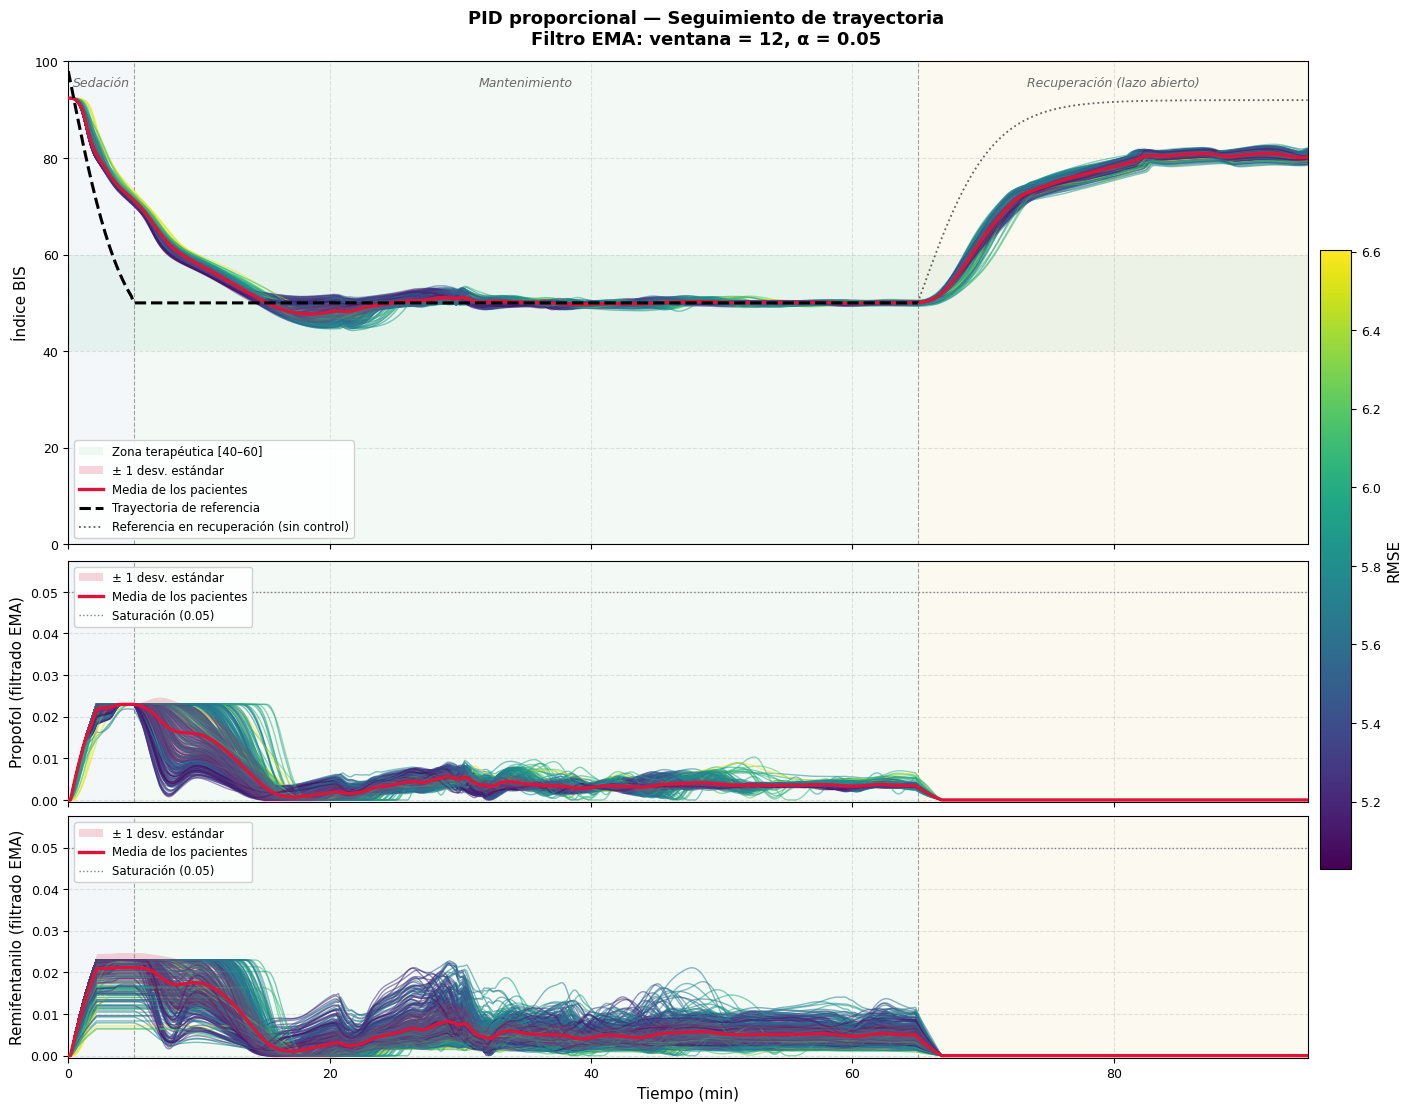

In [8]:
# =============================================================================
# GENERACIÓN DE LA FIGURA
# =============================================================================
fig, ejes = graficar_trayectorias(resultados, df_sel, referencia, eje_t, ESTILOS)
